In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

df = pd.read_csv('../../../data/processed/telco_customer_churn_clean.csv')

## 1) ประเภท Internet Service featute (Live_TV, LiveMovie) ต่อ Churn

In [2]:
def streaming_group(row):
    if row["StreamingTV"] == "Yes" and row["StreamingMovies"] == "Yes":
        return "both"
    elif row["StreamingTV"] == "Yes":
        return "tv_only"
    elif row["StreamingMovies"] == "Yes":
        return "movie_only"
    else:
        return "none"

df["StreamingGroup"] = df.apply(streaming_group, axis=1)

In [3]:
pd.crosstab(df["StreamingGroup"], df["Churn"], normalize="index")

Churn,No,Yes
StreamingGroup,,
both,0.705670,0.294330
movie_only,0.688131,0.311869
none,0.772009,0.227991
tv_only,0.683181,0.316819


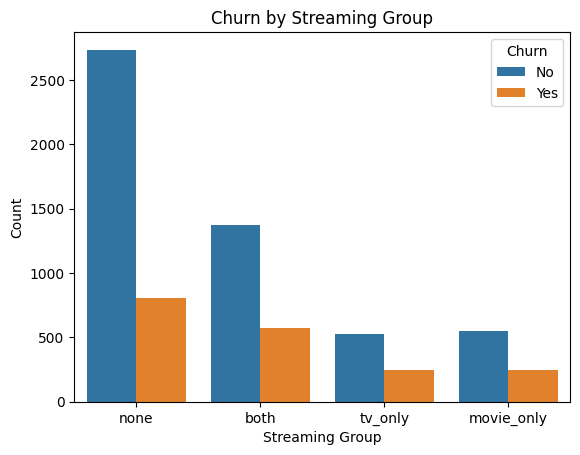

In [4]:
sns.countplot(data=df, x="StreamingGroup", hue="Churn")
plt.title("Churn by Streaming Group")
plt.xlabel("Streaming Group")
plt.ylabel("Count")
plt.legend(title="Churn", loc="upper right")
plt.show()

<Axes: xlabel='StreamingGroup'>

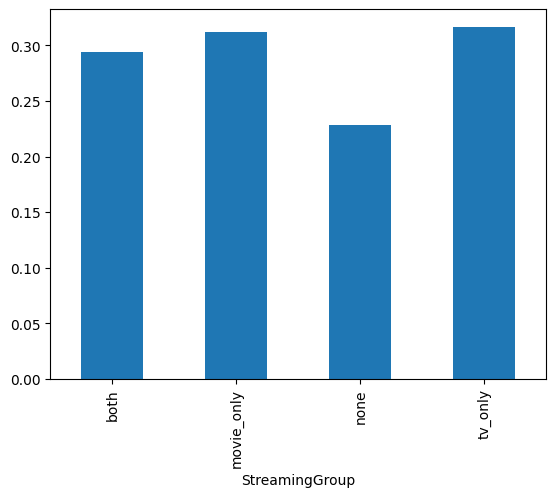

In [5]:
ct = pd.crosstab(
    df["StreamingGroup"],
    df["Churn"],
    normalize="index"
)

ct["Yes"].plot(kind="bar")


H1: Exclusive Feature (Streaming TV, Streaming Movie) ทําไห้ monly Charge สูงกว่าปกติ
 
H2: คนไช้ Exclusive Feature (Streaming TV, Streaming Movie) ส่วนใหญ่ ไช้ ประเภท Internet ที่ค่าใช้จ่ายสูง เช่น Fiber optic

H็3: คนไช้ Exclusive Feature (Streaming TV, Streaming Movie, both) อาจมี tenure ต่างกัน 

H4: คนไช้ Exclusive Feature (Streaming TV, Streaming Movie, both) อาจมี Data Size ต่างกัน

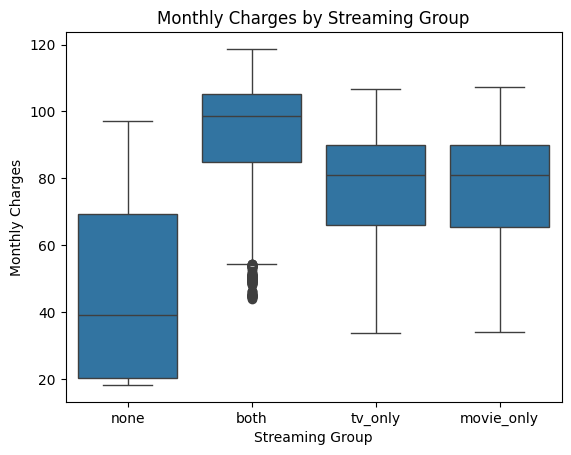

Mean Monthly Charges by Streaming Group:


StreamingGroup
both          93.237500
movie_only    76.811742
none          43.756024
tv_only       77.352803
Name: MonthlyCharges, dtype: float64

In [9]:
sns.boxplot(x="StreamingGroup", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Streaming Group")
plt.xlabel("Streaming Group")
plt.ylabel("Monthly Charges")
plt.show()

print("Mean Monthly Charges by Streaming Group:")
df.groupby("StreamingGroup")["MonthlyCharges"].mean()

#### ทดสอบ ว่า Exclusive Feature คนไช้ Internet service มีค่าไช้จ่ายสูง

In [10]:
pd.crosstab(
    df["StreamingGroup"],
    df["InternetService"],
    normalize="index"
)

InternetService,DSL,Fiber optic,No
StreamingGroup,,,
both,0.324742,0.675258,0.000000
movie_only,0.443182,0.556818,0.000000
none,0.314052,0.255361,0.430587
tv_only,0.426336,0.573664,0.000000


#### ผู้ใช้ streaming services อาจมี tenure ต่างกัน

<Axes: xlabel='StreamingGroup', ylabel='tenure'>

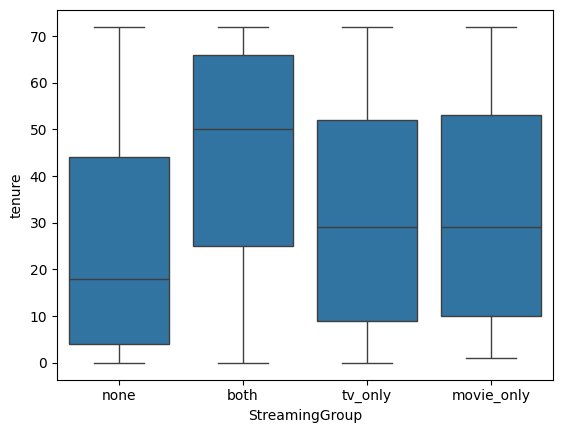

In [11]:
sns.boxplot(x="StreamingGroup", y="tenure", data=df)

### insight 1

    -Customers using streaming services
    tend to subscribe to Fiber optic internet
    and have higher MonthlyCharges.

    -Customers using both streaming services
    show higher average tenure.



H5:  คนไช้ Exclusive Feature (Streaming TV, Streaming Movie, both)  ส่วนใหญ่ เป็ร ประเภท Contract ระยะสั้น ทําให้ Churn สูง

In [12]:
pd.crosstab(df["StreamingGroup"], df["Contract"], normalize="index")

Contract,Month-to-month,One year,Two year
StreamingGroup,,,
both,0.419072,0.252577,0.328351
movie_only,0.619949,0.217172,0.162879
none,0.588600,0.183126,0.228273
tv_only,0.632334,0.211213,0.156454


<Axes: xlabel='StreamingGroup'>

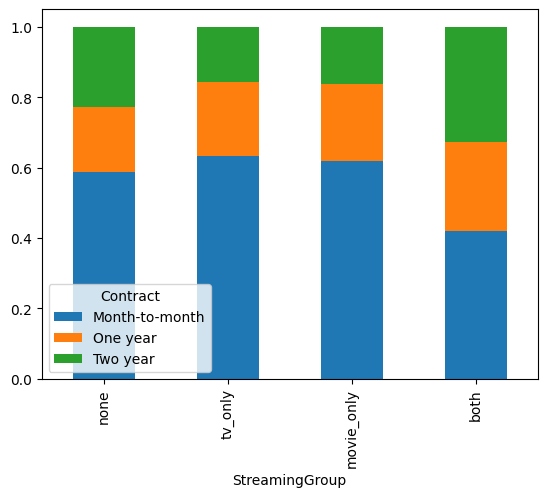

In [16]:
order = ["none", "tv_only", "movie_only", "both"]

ct = pd.crosstab(
    df["StreamingGroup"],
    df["Contract"],
    normalize="index"
).loc[order]

ct.plot(kind="bar", stacked=True)

### insight 2

    -Customers who use both streaming services
    are more likely to commit to longer contracts.

    -Heavy entertainment users
    tend to stay longer with the company.


Customers subscribing to both streaming services
show a significantly higher proportion of long-term contracts
(32.8% two-year contracts) compared to other groups.

This suggests that heavy entertainment users are more
committed to the service, which may explain their longer tenure.